In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Generar datos sintéticos (10 variables de comportamiento de cliente)
np.random.seed(42)
n_customers = 500
data = np.random.rand(n_customers, 10)

# Crear nombres de columnas para darle contexto de negocio
columns = ['Annual_Income', 'Spending_Score', 'Avg_Transaction', 'Frequency', 
           'Recency', 'Online_Engagement', 'Return_Rate', 'Coupon_Usage', 
           'Brand_Loyalty', 'Support_Calls']

df = pd.DataFrame(data, columns=columns)

# Escalar los datos (Paso OBLIGATORIO antes de PCA)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

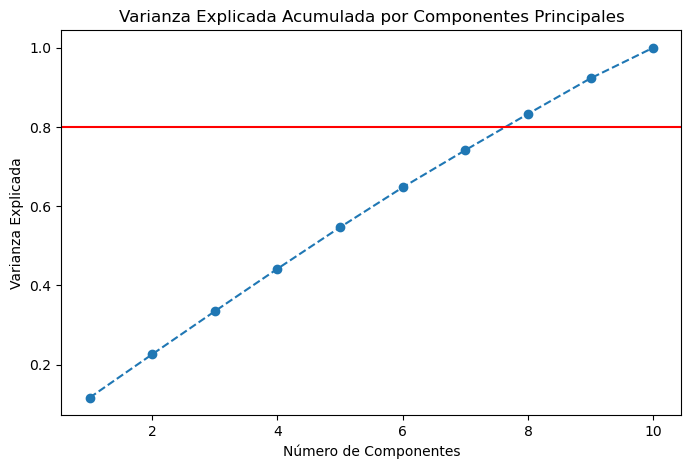

In [6]:
# Aplicar PCA
pca = PCA()
pca.fit(df_scaled)

# Calcular varianza explicada acumulada
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), cumulative_variance, marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada')
plt.axhline(y=0.8, color='r', linestyle='-') # Umbral del 80%
plt.show()

# Reducir a 3 componentes (para visualización y eficiencia)
pca_final = PCA(n_components=3)
df_pca = pca_final.fit_transform(df_scaled)

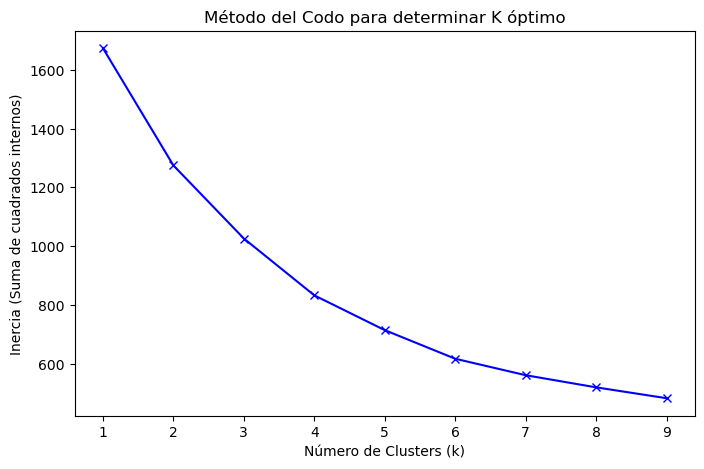

In [7]:
# Método del Codo (Elbow Method)
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (Suma de cuadrados internos)')
plt.title('Método del Codo para determinar K óptimo')
plt.show()

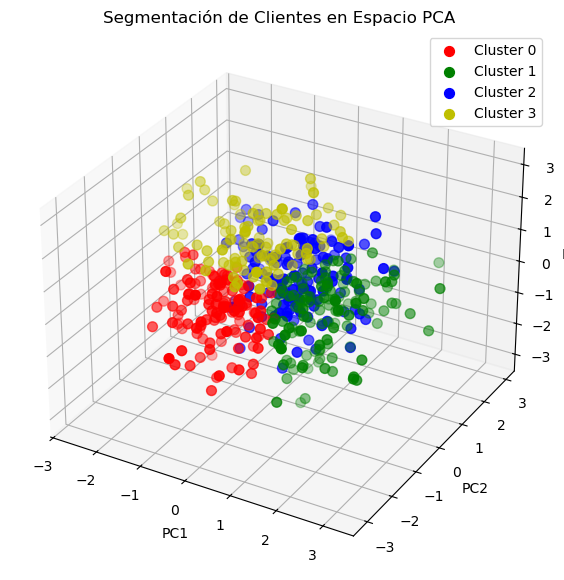

In [8]:
# Aplicar K-means con el k óptimo
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans_final.fit_transform(df_pca)
df['Cluster'] = kmeans_final.labels_

# Visualización 3D de los segmentos
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b', 'y']
for i in range(4):
    ax.scatter(df_pca[df['Cluster'] == i, 0], 
               df_pca[df['Cluster'] == i, 1], 
               df_pca[df['Cluster'] == i, 2], 
               c=colors[i], label=f'Cluster {i}', s=50)

ax.set_title('Segmentación de Clientes en Espacio PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.legend()
plt.show()